In [ ]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

[INFO] torch/torchvision versions not as required, installing nightly versions.
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu113
torch version: 2.9.1
torchvision version: 0.24.1


In [46]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

In [47]:
device = "cuda" if torch.cuda.is_available() else "mps"
device

'mps'

In [48]:
# Download pizza, steak, sushi images from GitHub
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

data_20_percent_path

[INFO] data/pizza_steak_sushi_20_percent directory exists, skipping download.


PosixPath('data/pizza_steak_sushi_20_percent')

In [49]:
# Setup directory paths to train and test images
train_dir = data_20_percent_path / "train"
test_dir = data_20_percent_path / "test"

In [50]:
# 1. Setup pretrained EffNetB2 weights
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT

# 2. Get EffNetB2 transforms
effnetb2_transforms = effnetb2_weights.transforms()

# 3. Setup pretrained model
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights) # could also use weights="DEFAULT"

# 4. Freeze the base layers in the model (this will freeze all layers to begin with)
for param in effnetb2.parameters():
    param.requires_grad = False

In [51]:
# Check out EffNetB2 classifier head
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

In [52]:
# 5. Update the classifier head
effnetb2.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True), # keep dropout layer same
    nn.Linear(in_features=1408, # keep in_features same 
              out_features=3)) # change out_features to suit our number of classes

In [53]:
def create_effnetb2_model(num_classes:int=3, 
                          seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head. 
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model. 
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    # 1, 2, 3. Create EffNetB2 pretrained weights, transforms and model
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # 4. Freeze all layers in base model
    for param in model.parameters():
        param.requires_grad = False

    # 5. Change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

In [54]:
effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=3,
                                                      seed=42)

In [55]:
# Setup DataLoaders
from going_modular.going_modular import data_setup
train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                                 test_dir=test_dir,
                                                                                                 transform=effnetb2_transforms,
                                                                                                 batch_size=32)

In [56]:
from going_modular.going_modular import engine

# Setup optimizer
optimizer = torch.optim.Adam(params=effnetb2.parameters(),
                             lr=1e-3)
# Setup loss function
loss_fn = torch.nn.CrossEntropyLoss()

# Set seeds for reproducibility and train the model
set_seeds()
effnetb2_results = engine.train(model=effnetb2,
                                train_dataloader=train_dataloader_effnetb2,
                                test_dataloader=test_dataloader_effnetb2,
                                epochs=10,
                                optimizer=optimizer,
                                loss_fn=loss_fn,
                                device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9817 | train_acc: 0.5729 | test_loss: 0.7343 | test_acc: 0.9625


KeyboardInterrupt: 

In [57]:
# تحقق من توفر MPS
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✅ Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("✅ Using CUDA")
else:
    device = torch.device("cpu")
    print("⚠️ Using CPU - This will be slow!")

print(f"Device: {device}")

✅ Using MPS (Apple Silicon GPU)
Device: mps


In [58]:
# نقل النموذج إلى MPS
effnetb2 = effnetb2.to(device)

# تأكد من أن البيانات تُنقل أيضاً (عادة يتم ذلك في engine.train)

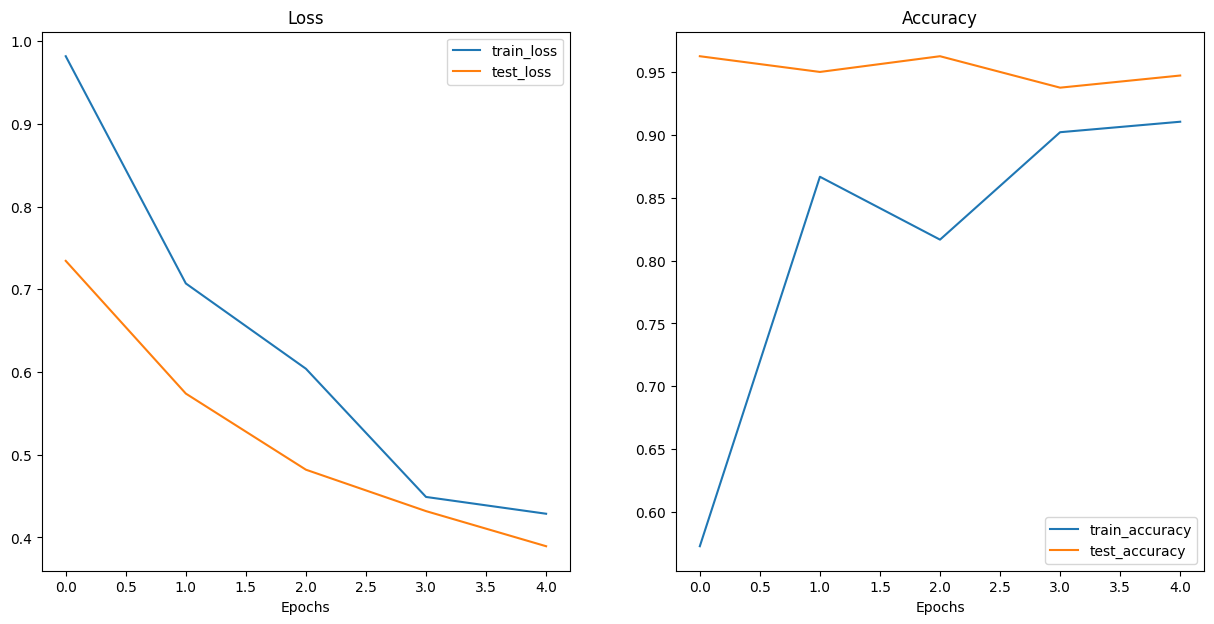

In [13]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_results)

In [60]:
# في Terminal
!pip install --upgrade torch torchvision torchaudio

In [61]:
!pip3 install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cpu

Looking in indexes: https://download.pytorch.org/whl/nightly/cpu


In [63]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"MPS built: {torch.backends.mps.is_built()}")

# اختبار سرعة MPS
if torch.backends.mps.is_available():
    # اختبار بسيط
    import time
    
    device_mps = torch.device("mps")
    device_cpu = torch.device("cpu")
    
    # إنشاء tensor كبير
    size = 5000
    
    # على CPU
    a_cpu = torch.randn(size, size)
    b_cpu = torch.randn(size, size)
    start = time.time()
    c_cpu = torch.matmul(a_cpu, b_cpu)
    cpu_time = time.time() - start
    print(f"CPU time: {cpu_time:.3f}s")
    
    # على MPS
    a_mps = torch.randn(size, size, device=device_mps)
    b_mps = torch.randn(size, size, device=device_mps)
    
    # Warm up
    torch.matmul(a_mps, b_mps)
    torch.mps.synchronize()
    
    start = time.time()
    c_mps = torch.matmul(a_mps, b_mps)
    torch.mps.synchronize()
    mps_time = time.time() - start
    print(f"MPS time: {mps_time:.3f}s")
    print(f"Speedup: {cpu_time/mps_time:.1f}x")

PyTorch version: 2.9.1
MPS available: True
MPS built: True
CPU time: 0.089s
MPS time: 0.039s
Speedup: 2.3x


In [64]:
# تأكد من نقل النموذج إلى MPS
device = torch.device("mps")
effnetb2 = effnetb2.to(device)

print(f"Model is on: {next(effnetb2.parameters()).device}")

Model is on: mps:0


In [65]:
import torch
import torchvision
from torch import nn

# 1. إعداد الجهاز
device = torch.device("mps")
print(f"✅ Using device: {device}")

# 2. إنشاء النموذج
def create_effnetb2_model(num_classes=3, seed=42):
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)
    
    # تجميد الطبقات
    for param in model.parameters():
        param.requires_grad = False
    
    # تغيير الـ classifier
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

# 3. إنشاء النموذج ونقله إلى MPS
effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=3, seed=42)
effnetb2 = effnetb2.to(device)  # ⬅️ مهم جداً!

# 4. التحقق
print(f"✅ Model is on: {next(effnetb2.parameters()).device}")

# 5. إعداد DataLoaders مع تحسينات
train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=effnetb2_transforms,
    batch_size=64,      # ⬅️ زيادة batch size
    num_workers=0       # ⬅️ 0 أفضل مع MPS
)

# 6. التدريب
optimizer = torch.optim.Adam(params=effnetb2.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

set_seeds()
effnetb2_results = engine.train(
    model=effnetb2,
    train_dataloader=train_dataloader_effnetb2,
    test_dataloader=test_dataloader_effnetb2,
    epochs=10,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device  # ⬅️ تأكد من تمرير device
)

✅ Using device: mps
✅ Model is on: mps:0


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0297 | train_acc: 0.5039 | test_loss: 0.8726 | test_acc: 0.8717
Epoch: 2 | train_loss: 0.8088 | train_acc: 0.7988 | test_loss: 0.7172 | test_acc: 0.8977
Epoch: 3 | train_loss: 0.7322 | train_acc: 0.8125 | test_loss: 0.6092 | test_acc: 0.9688
Epoch: 4 | train_loss: 0.5638 | train_acc: 0.9102 | test_loss: 0.5404 | test_acc: 0.9375
Epoch: 5 | train_loss: 0.5478 | train_acc: 0.8438 | test_loss: 0.5055 | test_acc: 0.9588
Epoch: 6 | train_loss: 0.5939 | train_acc: 0.8516 | test_loss: 0.4676 | test_acc: 0.9740
Epoch: 7 | train_loss: 0.5464 | train_acc: 0.7832 | test_loss: 0.4215 | test_acc: 0.9479
Epoch: 8 | train_loss: 0.5841 | train_acc: 0.7871 | test_loss: 0.4328 | test_acc: 0.9640
Epoch: 9 | train_loss: 0.4831 | train_acc: 0.8770 | test_loss: 0.4399 | test_acc: 0.9176
Epoch: 10 | train_loss: 0.5128 | train_acc: 0.7930 | test_loss: 0.3906 | test_acc: 0.9432


In [66]:
# الطريقة الصحيحة لأجهزة Mac
device = torch.device("mps")

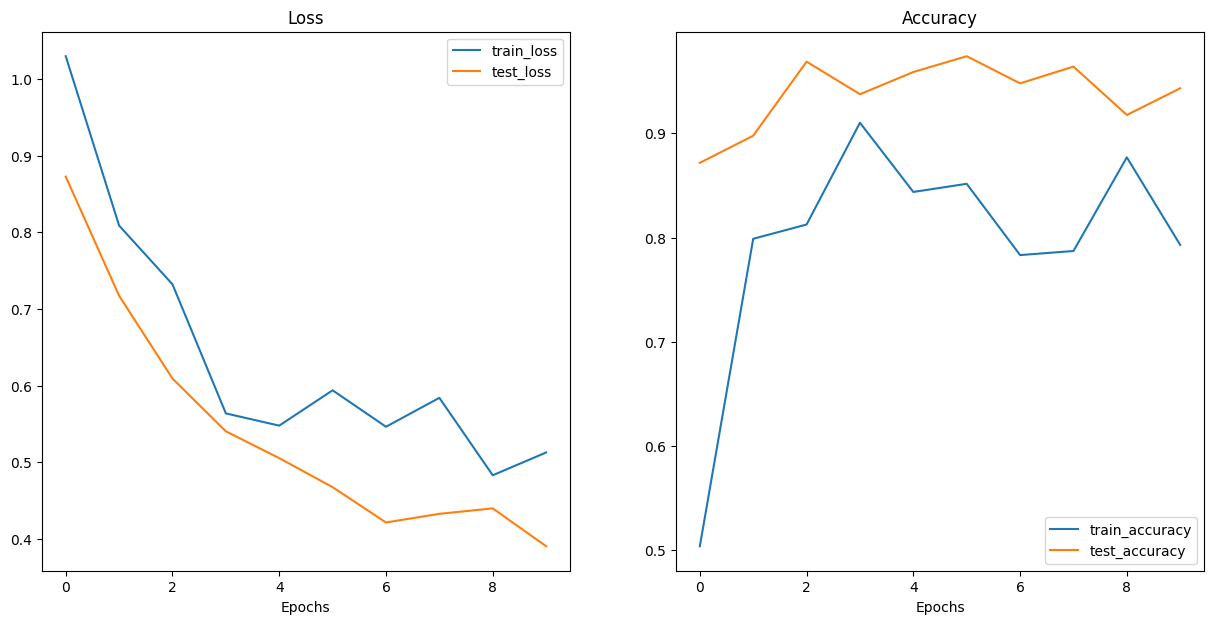

In [67]:
from helper_functions import plot_loss_curves

plot_loss_curves(effnetb2_results)

In [68]:
from going_modular.going_modular import utils

# Save the model
utils.save_model(model=effnetb2,
                 target_dir="models",
                 model_name="09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth


In [69]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_effnetb2_model_size = Path("models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly) 
print(f"Pretrained EffNetB2 feature extractor model size: {pretrained_effnetb2_model_size} MB")

Pretrained EffNetB2 feature extractor model size: 29 MB


In [70]:
# Count number of parameters in EffNetB2
effnetb2_total_params = sum(torch.numel(param) for param in effnetb2.parameters())
effnetb2_total_params

7705221

In [71]:
# Create a dictionary with EffNetB2 statistics
effnetb2_stats = {"test_loss": effnetb2_results["test_loss"][-1],
                  "test_acc": effnetb2_results["test_acc"][-1],
                  "number_of_parameters": effnetb2_total_params,
                  "model_size (MB)": pretrained_effnetb2_model_size}
effnetb2_stats

{'test_loss': 0.3905764122804006,
 'test_acc': 0.9431818181818182,
 'number_of_parameters': 7705221,
 'model_size (MB)': 29}

In [88]:
# Check out ViT heads layer
device = torch.device("mps")
vit = torchvision.models.vit_b_16().to(device)
vit.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

In [89]:
def create_vit_model(num_classes:int=3, 
                     seed:int=42):
    """Creates a ViT-B/16 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of target classes. Defaults to 3.
        seed (int, optional): random seed value for output layer. Defaults to 42.

    Returns:
        model (torch.nn.Module): ViT-B/16 feature extractor model. 
        transforms (torchvision.transforms): ViT-B/16 image transforms.
    """
    # Create ViT_B_16 pretrained weights, transforms and model
    weights = torchvision.models.ViT_B_16_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.vit_b_16(weights=weights).to(device)

    # Freeze all layers in model
    for param in model.parameters():
        param.requires_grad = False

    # Change classifier head to suit our needs (this will be trainable)
    torch.manual_seed(seed)
    model.heads = nn.Sequential(nn.Linear(in_features=768, # keep this the same as original model
                                          out_features=num_classes)) # update to reflect target number of classes
    
    return model, transforms

In [91]:
# Create ViT model and transforms
vit, vit_transforms = create_vit_model(num_classes=3,
                                       seed=42)
vit = vit.to(device)

In [94]:
# Setup ViT DataLoaders
from going_modular.going_modular import data_setup
train_dataloader_vit, test_dataloader_vit, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                       test_dir=test_dir,
                                                                                       transform=vit_transforms,
                                                                                       batch_size=64,num_workers=0)

In [95]:
from going_modular.going_modular import engine

# Setup optimizer
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=1e-3)
# Setup loss function
loss_fn = torch.nn.CrossEntropyLoss()

# Train ViT model with seeds set for reproducibility
set_seeds()
vit_results = engine.train(model=vit,
                           train_dataloader=train_dataloader_vit,
                           test_dataloader=test_dataloader_vit,
                           epochs=10,
                           optimizer=optimizer,
                           loss_fn=loss_fn,
                           device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

/Users/abdrhmn/.pyenv/versions/pytorch/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch: 1 | train_loss: 0.4329 | train_acc: 0.8828 | test_loss: 0.1748 | test_acc: 0.9541
Epoch: 2 | train_loss: 0.2036 | train_acc: 0.8984 | test_loss: 0.1611 | test_acc: 0.9593
Epoch: 3 | train_loss: 0.1611 | train_acc: 0.9688 | test_loss: 0.1558 | test_acc: 0.9389
Epoch: 4 | train_loss: 0.1167 | train_acc: 0.9668 | test_loss: 0.1343 | test_acc: 0.9744
Epoch: 5 | train_loss: 0.1139 | train_acc: 0.9688 | test_loss: 0.1154 | test_acc: 0.9692
Epoch: 6 | train_loss: 0.1588 | train_acc: 0.9102 | test_loss: 0.0970 | test_acc: 0.9692
Epoch: 7 | train_loss: 0.0892 | train_acc: 0.9766 | test_loss: 0.0934 | test_acc: 0.9692
Epoch: 8 | train_loss: 0.1358 | train_acc: 0.9160 | test_loss: 0.0874 | test_acc: 0.9744
Epoch: 9 | train_loss: 0.1117 | train_acc: 0.9824 | test_loss: 0.0853 | test_acc: 0.9796
Epoch: 10 | train_loss: 0.0801 | train_acc: 0.9805 | test_loss: 0.0782 | test_acc: 0.9744


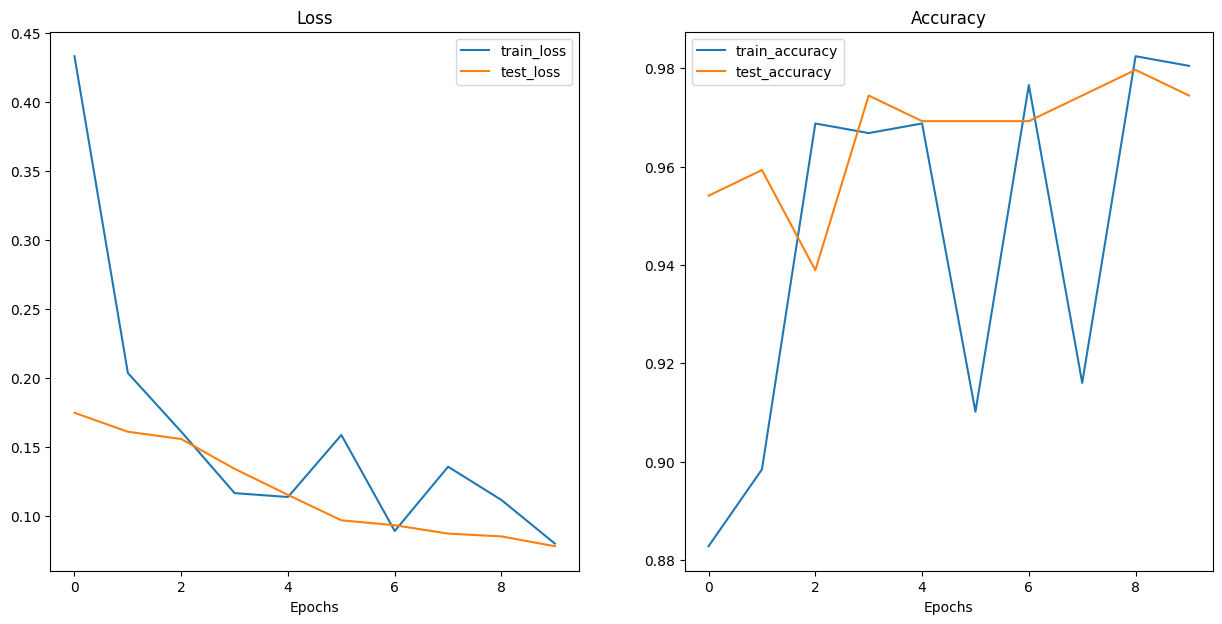

In [96]:
from helper_functions import plot_loss_curves

plot_loss_curves(vit_results)

In [97]:
# Save the model
from going_modular.going_modular import utils

utils.save_model(model=vit,
                 target_dir="models",
                 model_name="09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models/09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth


In [98]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_vit_model_size = Path("models/09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly) 
print(f"Pretrained ViT feature extractor model size: {pretrained_vit_model_size} MB")

Pretrained ViT feature extractor model size: 327 MB


In [99]:
# Count number of parameters in ViT
vit_total_params = sum(torch.numel(param) for param in vit.parameters())
vit_total_params

85800963

In [100]:
# Create ViT statistics dictionary
vit_stats = {"test_loss": vit_results["test_loss"][-1],
             "test_acc": vit_results["test_acc"][-1],
             "number_of_parameters": vit_total_params,
             "model_size (MB)": pretrained_vit_model_size}

vit_stats

{'test_loss': 0.07822524011135101,
 'test_acc': 0.9744318181818182,
 'number_of_parameters': 85800963,
 'model_size (MB)': 327}